# 🧠 Analisis Sentimen — Smart Tourism Ciayumajakuning
### Google Colab Pipeline (GPU T4) | PIC: Anggi & Ikhsan
#### Wilayah: Indramayu, Cirebon, Majalengka, Kuningan

**Pipeline:**
1. Mount Drive & install deps
2. Konfigurasi
3. Load CSV hasil scraping → gabung semua kategori
4. Preprocessing + normalisasi slang
5. Labeling semi-otomatis (lexicon)
6. Review & load label final
7. Split 80/10/10
8. Training Baseline ML (NB, SVM, DT)
9. Fine-tuning IndoBERT 3 epoch
10. Evaluasi & confusion matrix
11. Prediksi semua data
12. Export Hasil ke Excel (per Wilayah)

---


# 📁 SECTION 1 — Setup & Konfigurasi
> Mount Drive, install dependencies, dan set konfigurasi global

### 📌 Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_PROJECT_DIR = '/content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping'
for sub in ['sentiment-model/tokenizer','sentiment-baseline','data', 'Result']:
    os.makedirs(f'{BASE_PROJECT_DIR}/{sub}', exist_ok=True)
print('Drive terhubung. Folder siap.')

Mounted at /content/drive
Drive terhubung. Folder siap.


### 📌 Cell 2 — Install Dependencies

In [2]:
# ── CELL 2: Install Dependencies ────────────────────────────────────
!pip install -q transformers datasets scikit-learn pandas openpyxl \
             imbalanced-learn python-dotenv seaborn matplotlib joblib \
             sastrawi nltk wordcloud
print('Dependencies installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.0 MB/s eta 0:00:00
Dependencies installed.


### 📌 Cell 3 — Konfigurasi Global

In [3]:
WILAYAH_FILTER = ['Indramayu', 'Cirebon', 'Majalengka', 'Kuningan']
ANGGOTA        = ['Anggi', 'Ikhsan']
ANGGOTA_STR    = '_'.join(ANGGOTA)

# Path root untuk semua resource SmartTourism, konsisten dengan Cell 1
BASE_PROJECT_DIR = '/content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping'

# Path untuk input CSV scraping (berada di subfolder wilayah)
DATA_INPUT_ROOT = BASE_PROJECT_DIR

# Path untuk model baseline & Indobert
MODEL_OUTPUT_ROOT = BASE_PROJECT_DIR

# Path untuk hasil review manual & export final
RESULT_OUTPUT_DIR = os.path.join(BASE_PROJECT_DIR, 'Result')

# Jika CSV diupload langsung ke Colab session:
# DATA_INPUT_ROOT = '/content/data/scrap'

INDOBERT_BASE = 'indobenchmark/indobert-base-p1'
MAX_LENGTH    = 128
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-5

LABEL_MAP = {0: 'negatif', 1: 'positif'}

print(f'Config: {ANGGOTA} | {WILAYAH_FILTER}')

Config: ['Anggi', 'Ikhsan'] | ['Indramayu', 'Cirebon', 'Majalengka', 'Kuningan']


# 📊 SECTION 2 — Load & Preprocessing Data
> Load CSV scraping, preprocessing teks, normalisasi slang

### 📌 Cell 4 — Load CSV Scraping

In [7]:
import pandas as pd, numpy as np, os

def load_reviews_csv(data_input_root: str, wilayah_list: list) -> pd.DataFrame:
    """Gabung semua file *_reviews.csv sesuai filter wilayah, mencari di subfolder wilayah."""
    frames = []
    for wilayah in wilayah_list:
        # Menggunakan nama wilayah tanpa diubah ke lowercase untuk nama subdirektori
        wilayah_subdir = os.path.join(data_input_root, wilayah) # e.g., .../Scraping/Indramayu
        if not os.path.isdir(wilayah_subdir):
            print(f"Peringatan: Direktori '{wilayah_subdir}' tidak ditemukan, melewati wilayah ini.")
            continue

        for fname in os.listdir(wilayah_subdir):
            if not fname.endswith('_reviews.csv'):
                continue

            path = os.path.join(wilayah_subdir, fname)
            df   = pd.read_csv(path)
            df['wilayah']  = wilayah # Use the capitalized wilayah from the list

            # Extract category from filename (e.g., 'wisata_reviews.csv' -> 'Wisata')
            # Assuming format is [category]_reviews.csv or [something]_[category]_reviews.csv
            parts = fname.replace('_reviews.csv', '').split('_')
            if len(parts) > 0:
                # If filename is 'indramayu_wisata_reviews.csv' and wilayah is 'Indramayu'
                # then parts is ['indramayu', 'wisata']. We want 'wisata'.
                # If filename is 'wisata_reviews.csv', parts is ['wisata']. We want 'wisata'.
                if parts[0].lower() == wilayah.lower() and len(parts) > 1:
                    df['kategori'] = parts[1].capitalize()
                else:
                    df['kategori'] = parts[0].capitalize()
            else:
                df['kategori'] = 'Unknown' # Fallback if filename format is unexpected

            frames.append(df)

    if not frames:
        raise FileNotFoundError(f'Tidak ada CSV di {data_input_root} untuk {wilayah_list}. Pastikan struktur folder: {data_input_root}/Wilayah/file.csv')
    return pd.concat(frames, ignore_index=True)

df_raw = load_reviews_csv(DATA_INPUT_ROOT, WILAYAH_FILTER)

# Kolom ulasan: review_text
df_raw = df_raw[df_raw['review_text'].notna()].copy()
df_raw = df_raw.rename(columns={'review_text': 'teks_asli',
                                 'place_name':  'tempat_nama',
                                 'kategori':    'tipe_tempat',
                                 'rating':      'rating_google'})

# Jika ada kolom place_id → pakai sebagai tempat_kode sementara
if 'place_id' in df_raw.columns:
    df_raw['tempat_kode'] = df_raw['place_id'].str[:12].str.upper()
else:
    df_raw['tempat_kode'] = 'UNKNOWN'

df_raw = df_raw[df_raw['teks_asli'].str.len() > 5].reset_index(drop=True)
print(f'Total ulasan dimuat: {len(df_raw)}')
print(df_raw['wilayah'].value_counts())
print(df_raw['tipe_tempat'].value_counts())
df_raw[['tempat_nama','wilayah','tipe_tempat','teks_asli','rating_google']].head()

Total ulasan dimuat: 10334
wilayah
Kuningan      3367
Majalengka    3286
Cirebon       2209
Indramayu     1472
Name: count, dtype: int64
tipe_tempat
Wisata       3620
Nongkrong    3466
Kuliner      3248
Name: count, dtype: int64


,tempat_nama,wilayah,tipe_tempat,teks_asli,rating_google
0,Pantai Tirtamaya,Indramayu,Kuliner,"Enak buat bengong ,makan bareng keluarga pake ...",4
1,Pantai Tirtamaya,Indramayu,Kuliner,Tempat nya sejuk dan nyaman,5
2,Pantai Tirtamaya,Indramayu,Kuliner,"ga sengaja melipir ke pantai, lumayan bersih p...",5
3,Pantai Tirtamaya,Indramayu,Kuliner,"Dulu ramai. Apalagi di hari Minggu, dr pagi sa...",5
4,Pantai Tirtamaya,Indramayu,Kuliner,Alfanya cocok jauh dari minimar,5


### 📌 Cell 5 — Preprocessing Teks

In [8]:
# ── CELL 5: Preprocessing Teks (mengikuti pipeline referensi) ───────
import re, string, nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords')
nltk.download('punkt_tab')

pd.options.mode.chained_assignment = None

# Kamus slang — Indramayu + Cirebon + umum
SLANG_DICT = {
    '@':'di', 'gak':'tidak', 'ga':'tidak', 'tdk':'tidak', 'ngga':'tidak',
    'gk':'tidak', 'g':'tidak', 'tdk':'tidak', 'bgt':'banget',
    'bgs':'bagus', 'maks':'maksimal', 'abis':'habis',
    'masi':'masih', 'bs':'bisa', 'hrs':'harus', 'sdh':'sudah',
    'blm':'belum', 'udh':'sudah', 'aja':'saja', 'yg':'yang',
    'dgn':'dengan', 'utk':'untuk', 'krn':'karena',
    # Khas Indramayu / Cirebon
    'ewean':'tidak', 'ora':'tidak', 'sing':'yang', 'maning':'lagi',
    'arep':'mau', 'nganggo':'pakai', 'apik':'bagus', 'ayu':'cantik',
    'mantap':'bagus', 'keren':'bagus', 'enak':'lezat', 'yummy':'lezat',
    'murah':'terjangkau', 'rame':'ramai',
}

# Stemmer Sastrawi
_factory = StemmerFactory()
_stemmer = _factory.create_stemmer()

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.strip()

def casefoldingText(text):
    return text.lower()

def fix_slangwords(text):
    return ' '.join(SLANG_DICT.get(w.lower(), w) for w in text.split())

def tokenizingText(text):
    return word_tokenize(text)

def filteringText(tokens):
    id_stop = set(stopwords.words('indonesian'))
    en_stop = set(stopwords.words('english'))
    custom  = {'iya','yaa','gak','nya','na','sih','ku','di','ga','ya',
               'gaa','loh','kah','woi','woii','woy','dong','deh','nih'}
    all_stop = id_stop | en_stop | custom
    return [t for t in tokens if t not in all_stop]

def toSentence(tokens):
    return ' '.join(tokens)

# Jalankan pipeline bertahap
df_raw['text_clean']    = df_raw['teks_asli'].apply(cleaningText)
df_raw['text_casefolded']= df_raw['text_clean'].apply(casefoldingText)
df_raw['text_slang']    = df_raw['text_casefolded'].apply(fix_slangwords)
df_raw['text_tokens']   = df_raw['text_slang'].apply(tokenizingText)
df_raw['text_filtered'] = df_raw['text_tokens'].apply(filteringText)
df_raw['teks_bersih']   = df_raw['text_filtered'].apply(toSentence)

# Buang baris kosong
df_raw = df_raw[df_raw['teks_bersih'].str.len() > 5].reset_index(drop=True)
print(f'Setelah preprocessing: {len(df_raw)} baris')
df_raw[['teks_asli','teks_bersih']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Setelah preprocessing: 10278 baris


,teks_asli,teks_bersih
0,"Enak buat bengong ,makan bareng keluarga pake ...",lezat bengong makan bareng keluarga pake tikar
1,Tempat nya sejuk dan nyaman,sejuk nyaman
2,"ga sengaja melipir ke pantai, lumayan bersih p...",sengaja melipir pantai lumayan bersih pantai s...
3,"Dulu ramai. Apalagi di hari Minggu, dr pagi sa...",ramai minggu dr pagi malam ramai sepi
4,Alfanya cocok jauh dari minimar,alfanya cocok minimar


# 🏷️ SECTION 3 — Labeling Semi-Otomatis
> Labeling lexicon, WordCloud eksplorasi, review manual label

### 📌 Cell 6 — Labeling dengan Lexicon Skor Numerik

Kata positif dimuat: 3609
Kata negatif dimuat: 6607

Distribusi label otomatis:
label_otomatis
positif    6498
negatif    2633
netral     1147
Name: count, dtype: int64


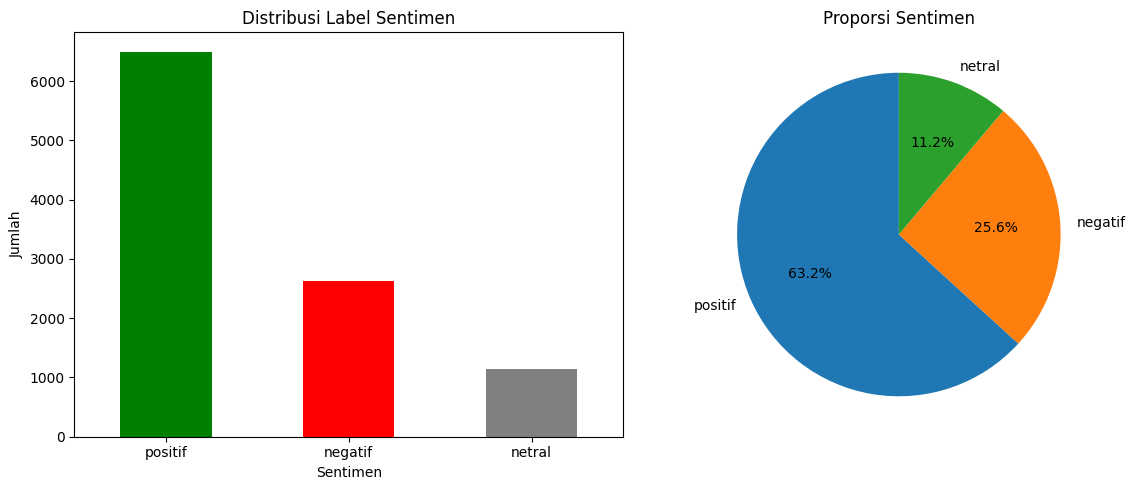


⚠️  Export ke: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/Result/review_label_Anggi_Ikhsan.xlsx
Buka file → isi kolom label_final (positif/negatif) → re-upload ke Drive.


In [9]:
# Mengunduh lexicon positif/negatif Indonesia dari GitHub (angelmetanosaa/dataset)
import csv, requests
from io import StringIO

lexicon_positive = {}
resp = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if resp.status_code == 200:
    for row in csv.reader(StringIO(resp.text), delimiter=','):
        try: lexicon_positive[row[0]] = int(row[1])
        except: pass
print(f'Kata positif dimuat: {len(lexicon_positive)}')

lexicon_negative = {}
resp = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if resp.status_code == 200:
    for row in csv.reader(StringIO(resp.text), delimiter=','):
        try: lexicon_negative[row[0]] = int(row[1])
        except: pass
print(f'Kata negatif dimuat: {len(lexicon_negative)}')

def sentiment_analysis_lexicon(tokens):
    """Hitung skor: positif jika >0, negatif jika <0, netral jika =0."""
    score = 0
    for w in tokens:
        if w in lexicon_positive: score += lexicon_positive[w]
        if w in lexicon_negative: score += lexicon_negative[w]
    if score > 0:  return score, 'positif'
    elif score < 0: return score, 'negatif'
    else:           return score, 'netral'

results = df_raw['text_filtered'].apply(sentiment_analysis_lexicon)
results = list(zip(*results))
df_raw['polarity_score']  = results[0]
df_raw['label_otomatis']  = results[1]

print('\nDistribusi label otomatis:')
print(df_raw['label_otomatis'].value_counts())

# Visualisasi distribusi
import matplotlib.pyplot as plt

sentiment_counts = df_raw['label_otomatis'].value_counts()
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sentiment_counts.plot(kind='bar', color=['green','red','gray'][:len(sentiment_counts)])
plt.title('Distribusi Label Sentimen')
plt.xlabel('Sentimen'); plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(sentiment_counts.values, labels=sentiment_counts.index,
        autopct='%1.1f%%', startangle=90)
plt.title('Proporsi Sentimen')

plt.tight_layout(); plt.show()

REVIEW_PATH = f'{RESULT_OUTPUT_DIR}/review_label_{ANGGOTA_STR}.xlsx'
df_raw[['tempat_nama','wilayah','tipe_tempat','teks_asli','teks_bersih',
        'rating_google','polarity_score','label_otomatis']].to_excel(REVIEW_PATH, index=False)
print(f'\n⚠️  Export ke: {REVIEW_PATH}')
print('Buka file → isi kolom label_final (positif/negatif) → re-upload ke Drive.')

### 📌 Cell 6b — WordCloud Eksplorasi per Label

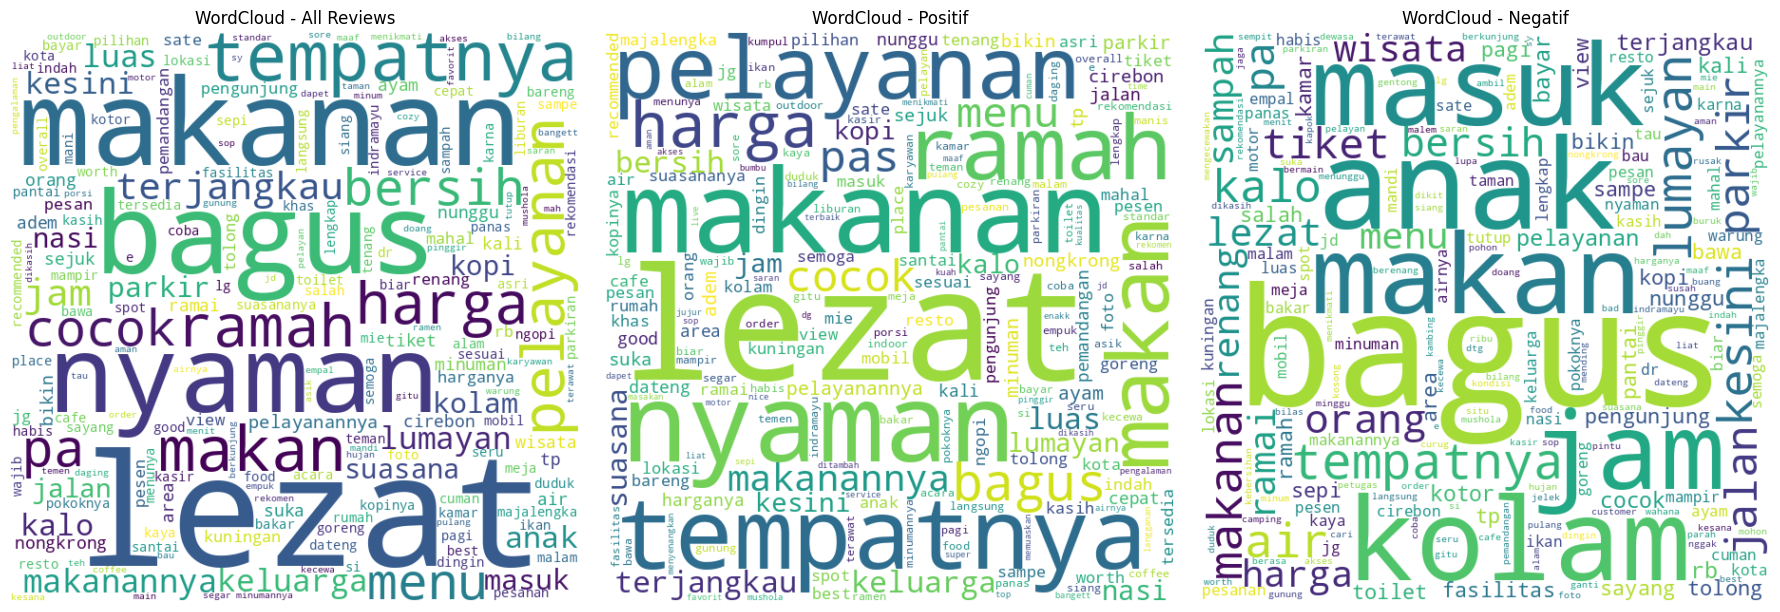

In [10]:
# ── CELL 6b: WordCloud Eksplorasi per Label ──────────────────────────
from wordcloud import WordCloud, STOPWORDS

try:
    ind_stop = set(stopwords.words('indonesian'))
except: ind_stop = set()
custom_stop = {'rt','amp','jang','klo','gk','ga','yg','nya','juga','udah',
               'oke','aja','yang','ok','buka','beli','pake','banget'}
all_stopwords = STOPWORDS | ind_stop | custom_stop

def join_texts(series):
    texts = []
    for v in series.dropna():
        texts.append(' '.join(v) if isinstance(v, (list,tuple)) else str(v))
    return ' '.join(texts)

text_all = join_texts(df_raw['teks_bersih'])
text_pos = join_texts(df_raw.loc[df_raw['label_otomatis']=='positif','teks_bersih'])
text_neg = join_texts(df_raw.loc[df_raw['label_otomatis']=='negatif','teks_bersih'])

if not text_pos.strip(): text_pos = 'tidak ada'
if not text_neg.strip(): text_neg = 'tidak ada'

plt.figure(figsize=(18, 6))
for i, (title, txt) in enumerate([
        ('All Reviews', text_all),
        ('Positif', text_pos),
        ('Negatif', text_neg)]):
    plt.subplot(1, 3, i+1)
    wc = WordCloud(background_color='white', width=600, height=600,
                   stopwords=all_stopwords, max_words=200,
                   collocations=False).generate(txt)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off'); plt.title(f'WordCloud - {title}')
plt.tight_layout(); plt.show()


### 📌 Cell 7 — Load Hasil Review Manual
> ⚠️ Jalankan setelah mengisi `label_final` di Excel dan re-upload ke Drive.

In [11]:
# Jalankan setelah mengisi label_final di Excel dan re-upload ke Drive.

REVIEWED_PATH = f'{RESULT_OUTPUT_DIR}/review_label_{ANGGOTA_STR}.xlsx'
df_labeled    = pd.read_excel(REVIEWED_PATH)

if 'label_final' not in df_labeled.columns:
    df_labeled['label_final'] = df_labeled['label_otomatis']
    print('⚠️ Menggunakan label otomatis (belum direview manual)')

df_labeled = df_labeled[df_labeled['label_final'].isin(['positif','negatif'])].copy()
df_labeled['label_id'] = df_labeled['label_final'].map({'negatif': 0, 'positif': 1})

print(f'Data siap training: {len(df_labeled)} baris')
print(df_labeled['label_final'].value_counts())

⚠️ Menggunakan label otomatis (belum direview manual)
Data siap training: 9131 baris
label_final
positif    6498
negatif    2633
Name: count, dtype: int64


# ✂️ SECTION 4 — Split Data & Baseline ML
> Split 80/10/10 dan training model baseline (NB, SVM, DT)

### 📌 Cell 8 — Split Data 80/10/10

In [12]:
# ── CELL 8: Split 80/10/10 ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_labeled['teks_bersih'].values
y = df_labeled['label_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Train: 6391 | Val: 913 | Test: 1827


### 📌 Cell 9 — Training Baseline ML (NB, SVM, Decision Tree)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
import joblib

TFIDF = TfidfVectorizer(ngram_range=(1,2), max_features=10000, sublinear_tf=True)

BASELINE_MODELS = {
    'naive_bayes':   Pipeline([('tfidf', TFIDF), ('clf', MultinomialNB())]),
    'svm':           Pipeline([('tfidf', TFIDF), ('clf', CalibratedClassifierCV(LinearSVC()))]),
    'decision_tree': Pipeline([('tfidf', TFIDF), ('clf', DecisionTreeClassifier(random_state=42))]),
}

baseline_results = {}
for name, model in BASELINE_MODELS.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    baseline_results[name] = acc
    print(f'\n=== {name.upper()} === Acc: {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['negatif','positif']))
    path = f'{MODEL_OUTPUT_ROOT}/sentiment-baseline/{name}.pkl'
    joblib.dump(model, path)
    print(f'Saved: {path}')

best = max(baseline_results, key=baseline_results.get)
print(f'\nBaseline terbaik: {best} ({baseline_results[best]:.4f})')


=== NAIVE_BAYES === Acc: 0.7876
              precision    recall  f1-score   support

     negatif       0.88      0.31      0.45       527
     positif       0.78      0.98      0.87      1300

    accuracy                           0.79      1827
   macro avg       0.83      0.64      0.66      1827
weighted avg       0.81      0.79      0.75      1827

Saved: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/sentiment-baseline/naive_bayes.pkl

=== SVM === Acc: 0.9064
              precision    recall  f1-score   support

     negatif       0.85      0.82      0.83       527
     positif       0.93      0.94      0.93      1300

    accuracy                           0.91      1827
   macro avg       0.89      0.88      0.88      1827
weighted avg       0.91      0.91      0.91      1827

Saved: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/sentiment-baseline/svm.pkl

=== DECISION_TREE === Acc: 0.8199
              precision    recall  f1-score   sup

# 🤖 SECTION 5 — Fine-tuning IndoBERT
> Setup IndoBERT, training loop 3 epoch, evaluasi test set

### 📌 Cell 10 — Setup IndoBERT & DataLoader

In [17]:
# ── CELL 10: Setup IndoBERT ──────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import f1_score

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

tokenizer = AutoTokenizer.from_pretrained(INDOBERT_BASE)

class SentimenDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(list(texts), truncation=True, padding=True, max_length=MAX_LENGTH)
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k,v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[i])
        return item

train_dl = DataLoader(SentimenDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(SentimenDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_dl  = DataLoader(SentimenDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

model_bert = AutoModelForSequenceClassification.from_pretrained(INDOBERT_BASE, num_labels=2).to(device)
optimizer  = AdamW(model_bert.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps= len(train_dl) * EPOCHS
scheduler  = get_linear_schedule_with_warmup(optimizer, total_steps//10, total_steps)
print(f'Total steps: {total_steps}')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total steps: 1200


### 📌 Cell 11 — Training Loop IndoBERT (3 Epoch)

In [18]:
best_val_f1 = 0

for epoch in range(EPOCHS):
    model_bert.train()
    total_loss = 0
    for batch in train_dl:
        batch      = {k: v.to(device) for k,v in batch.items()}
        outputs    = model_bert(**batch)
        loss       = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()

    model_bert.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch in val_dl:
            batch = {k: v.to(device) for k,v in batch.items()}
            preds = torch.argmax(model_bert(**batch).logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch['labels'].cpu().numpy())

    val_f1 = f1_score(val_true, val_preds, average='macro')
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_dl):.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model_bert.save_pretrained(f'{MODEL_OUTPUT_ROOT}/sentiment-model')
        tokenizer.save_pretrained(f'{MODEL_OUTPUT_ROOT}/sentiment-model/tokenizer')
        print(f'  ✅ Model terbaik disimpan (Val F1: {best_val_f1:.4f})')

print(f'\nTraining selesai. Best Val F1: {best_val_f1:.4f}')

Epoch 1/3 | Loss: 0.3938 | Val F1: 0.8406


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model terbaik disimpan (Val F1: 0.8406)
Epoch 2/3 | Loss: 0.2063 | Val F1: 0.8615


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model terbaik disimpan (Val F1: 0.8615)
Epoch 3/3 | Loss: 0.1054 | Val F1: 0.8718


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model terbaik disimpan (Val F1: 0.8718)

Training selesai. Best Val F1: 0.8718


### 📌 Cell 12 — Evaluasi Final di Test Set

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== EVALUASI INDOBERT ===
              precision    recall  f1-score   support

     negatif       0.83      0.79      0.81       527
     positif       0.92      0.93      0.93      1300

    accuracy                           0.89      1827
   macro avg       0.87      0.86      0.87      1827
weighted avg       0.89      0.89      0.89      1827



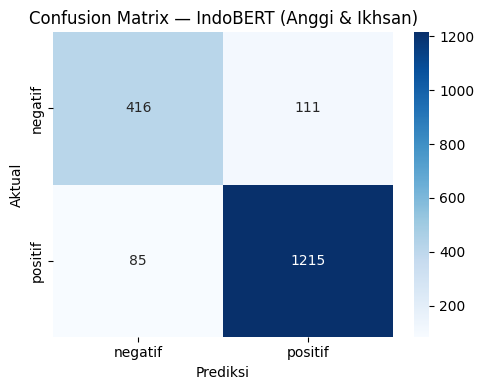

Gambar disimpan: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/confusion_matrix_Anggi_Ikhsan.png


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load model terbaik
from transformers import AutoModelForSequenceClassification, AutoTokenizer as AT
model_final  = AutoModelForSequenceClassification.from_pretrained(f'{MODEL_OUTPUT_ROOT}/sentiment-model').to(device)
tok_final    = AT.from_pretrained(f'{MODEL_OUTPUT_ROOT}/sentiment-model/tokenizer')
model_final.eval()

test_preds, test_true, test_probs = [], [], []
with torch.no_grad():
    for batch in test_dl:
        batch  = {k: v.to(device) for k,v in batch.items()}
        out    = model_final(**batch)
        probs  = torch.softmax(out.logits, dim=1).cpu().numpy()
        preds  = probs.argmax(axis=1)
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_true.extend(batch['labels'].cpu().numpy())

print('=== EVALUASI INDOBERT ===')
print(classification_report(test_true, test_preds, target_names=['negatif','positif']))

cm = confusion_matrix(test_true, test_preds)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negatif','positif'],
            yticklabels=['negatif','positif'], ax=ax)
ax.set_title(f'Confusion Matrix — IndoBERT ({' & '.join(ANGGOTA)})')
ax.set_ylabel('Aktual'); ax.set_xlabel('Prediksi')
plt.tight_layout()
plt.savefig(f'{MODEL_OUTPUT_ROOT}/confusion_matrix_{ANGGOTA_STR}.png', dpi=150)
plt.show()
print(f'Gambar disimpan: {MODEL_OUTPUT_ROOT}/confusion_matrix_{ANGGOTA_STR}.png')

# 📤 SECTION 6 — Prediksi & Export Hasil
> Prediksi semua data berlabel dan export ke Excel per wilayah

### 📌 Cell 13 — Prediksi Semua Data Berlabel

In [20]:
# ── CELL 13: Prediksi Semua Data Berlabel ───────────────────────────
def predict_text(text: str):
    inp  = tok_final(text, return_tensors='pt', truncation=True, max_length=MAX_LENGTH).to(device)
    with torch.no_grad():
        logits = model_final(**inp).logits
    probs    = torch.softmax(logits, dim=1)[0].cpu().tolist()
    label_id = int(torch.argmax(logits).item())
    return LABEL_MAP[label_id], round(probs[label_id], 4)

print('Memproses prediksi semua data...')
preds = [predict_text(t) for t in df_labeled['teks_bersih']]
df_labeled['sentimen_pred']   = [p[0] for p in preds]
df_labeled['confidence_pred'] = [p[1] for p in preds]
print(f'Selesai: {len(df_labeled)} baris')
print(df_labeled['sentimen_pred'].value_counts())


Memproses prediksi semua data...
Selesai: 9131 baris
sentimen_pred
positif    6582
negatif    2549
Name: count, dtype: int64


### 📌 Cell 15 — Export Excel per Wilayah
> 💡 Kirim file-file ini ke ketua untuk import manual via seed database.

In [21]:
export_cols = ['tempat_nama','wilayah','tipe_tempat','tempat_kode',
               'teks_asli','teks_bersih','label_final',
               'sentimen_pred','confidence_pred']

wilayah_list = df_labeled['wilayah'].unique()
for w in wilayah_list:
    OUTPUT_PATH = f'{RESULT_OUTPUT_DIR}/hasil_sentimen_{str(w).capitalize()}.xlsx'
    df_w = df_labeled[df_labeled['wilayah'] == w]
    df_w[[c for c in export_cols if c in df_w.columns]].to_excel(OUTPUT_PATH, index=False)
    print(f'Hasil {w} diekspor ke: {OUTPUT_PATH}')

print('Kirim file-file ini ke ketua untuk import manual via seed database.')

Hasil Indramayu diekspor ke: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/Result/hasil_sentimen_Indramayu.xlsx
Hasil Cirebon diekspor ke: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/Result/hasil_sentimen_Cirebon.xlsx
Hasil Majalengka diekspor ke: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/Result/hasil_sentimen_Majalengka.xlsx
Hasil Kuningan diekspor ke: /content/drive/MyDrive/SmartTourism/Datasets/Documents/Scraping/Result/hasil_sentimen_Kuningan.xlsx
Kirim file-file ini ke ketua untuk import manual via seed database.
